In [1]:
#IMport ANd Data Load

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import ipywidgets as widgets
from IPython.display import display, HTML

df_original = pd.read_csv("healthcare_cleaned.csv")

print(f"✅ Data Loaded: {df_original.shape[0]} rows, {df_original.shape[1]} columns")
df_original.head()

✅ Data Loaded: 54860 rows, 15 columns


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
#Build Realistic Billing + Feature Engineering

df = df_original.copy()

# ── Add Length of Stay ────────────────────────────────
df["Length of Stay"] = (
    pd.to_datetime(df["Discharge Date"]) -
    pd.to_datetime(df["Date of Admission"])
).dt.days

# ── Encode All Categorical Columns ───────────────────
encoders = {}
categorical_columns = [
    "Gender",
    "Medical Condition",
    "Admission Type",
    "Insurance Provider",
    "Medication",      
    "Test Results"     
]

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# ── Features & Target ─────────────────────────────────
X = df[[
    "Age",
    "Gender",
    "Medical Condition",
    "Admission Type",
    "Insurance Provider",
    "Length of Stay",   
    "Medication",       
    "Test Results"     
]]

y = df["Billing Amount"]

print("✅ Features ready:", list(X.columns))
print(f"   Shape: {X.shape}")

✅ Features ready: ['Age', 'Gender', 'Medical Condition', 'Admission Type', 'Insurance Provider', 'Length of Stay', 'Medication', 'Test Results']
   Shape: (54860, 8)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"✅ Model Trained")
print(f"   R² Score : {r2:.4f}")
print(f"   MAE      : ${mae:,.2f}")

✅ Model Trained
   R² Score : -0.0037
   MAE      : $12,100.06


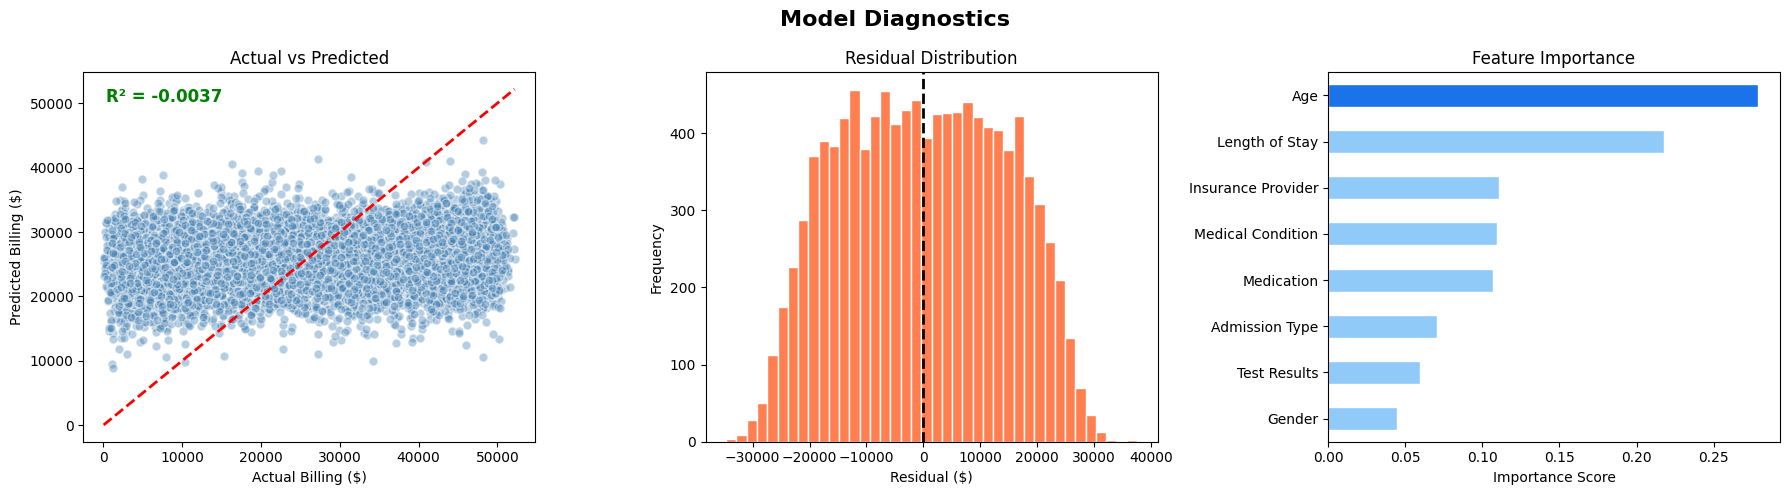

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Diagnostics", fontsize=16, fontweight="bold")

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.4, color="steelblue", edgecolors="white", s=40)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], "r--", lw=2)
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Billing ($)")
axes[0].set_ylabel("Predicted Billing ($)")
axes[0].text(0.05, 0.92, f"R² = {r2:.4f}", transform=axes[0].transAxes,
             fontsize=12, color="green", fontweight="bold")

# 2. Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color="coral", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", lw=2)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual ($)")
axes[1].set_ylabel("Frequency")

# 3. Feature Importance
importances = pd.Series(
    model.feature_importances_,
    index=["Age", "Gender", "Medical Condition",
           "Admission Type", "Insurance Provider",
           "Length of Stay", "Medication", "Test Results"]
).sort_values()

colors = ["#1a73e8" if v == importances.max() else "#90caf9" for v in importances]
importances.plot(kind="barh", ax=axes[2], color=colors, edgecolor="white")
axes[2].set_title("Feature Importance")
axes[2].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()

In [8]:
result_label = widgets.HTML(value="""
<div style='
    padding:20px;
    border:2px dashed #90caf9;
    border-radius:10px;
    text-align:center;
    color:#888;
    font-size:15px;
    background:#f9f9f9;
'>
    🔍 Fill in patient details and click <b>Predict</b> to see results
</div>
""")

# ── Widgets ───────────────────────────────────────────
age_slider = widgets.IntSlider(
    value=40, min=1, max=90,
    description="Age:",
    style={"description_width": "160px"},
    layout=widgets.Layout(width="100%")
)

gender_dd = widgets.Dropdown(
    options=sorted(df_original["Gender"].unique()),
    description="Gender:",
    style={"description_width": "160px"},
    layout=widgets.Layout(width="100%")
)

condition_dd = widgets.Dropdown(
    options=sorted(df_original["Medical Condition"].unique()),
    description="Medical Condition:",
    style={"description_width": "160px"},
    layout=widgets.Layout(width="100%")
)

admission_dd = widgets.Dropdown(
    options=sorted(df_original["Admission Type"].unique()),
    description="Admission Type:",
    style={"description_width": "160px"},
    layout=widgets.Layout(width="100%")
)

insurance_dd = widgets.Dropdown(
    options=sorted(df_original["Insurance Provider"].unique()),
    description="Insurance Provider:",
    style={"description_width": "160px"},
    layout=widgets.Layout(width="100%")
)


los_slider = widgets.IntSlider(
    value=5, min=1, max=60,
    description="Length of Stay:",
    style={"description_width": "160px"},
    layout=widgets.Layout(width="100%")
)

medication_dd = widgets.Dropdown(
    options=sorted(df_original["Medication"].unique()),
    description="Medication:",
    style={"description_width": "160px"},
    layout=widgets.Layout(width="100%")
)

test_results_dd = widgets.Dropdown(
    options=sorted(df_original["Test Results"].unique()),
    description="Test Results:",
    style={"description_width": "160px"},
    layout=widgets.Layout(width="100%")
)

predict_btn = widgets.Button(
    description="Predict Billing Cost",
    button_style="success",
    icon="check",
    layout=widgets.Layout(width="100%", height="42px")
)

reset_btn = widgets.Button(
    description="Reset",
    button_style="warning",
    icon="refresh",
    layout=widgets.Layout(width="100%", height="42px")
)

# ── Two Column Layout ─────────────────────────────────
left_col = widgets.VBox(
    [age_slider, condition_dd, insurance_dd, los_slider],
    layout=widgets.Layout(width="48%", padding="0 10px 0 0")
)

right_col = widgets.VBox(
    [gender_dd, admission_dd, medication_dd, test_results_dd],
    layout=widgets.Layout(width="48%", padding="0 0 0 10px")
)

two_col = widgets.HBox(
    [left_col, right_col],
    layout=widgets.Layout(width="100%")
)

btn_row = widgets.HBox(
    [predict_btn, reset_btn],
    layout=widgets.Layout(width="100%", margin="15px 0 0 0")
)

# ── Predict Function ──────────────────────────────────
def predict_cost(b):
    user_inputs = {
        "Age":                age_slider.value,
        "Gender":             gender_dd.value,
        "Medical Condition":  condition_dd.value,
        "Admission Type":     admission_dd.value,
        "Insurance Provider": insurance_dd.value,
        "Length of Stay":     f"{los_slider.value} days",
        "Medication":         medication_dd.value,
        "Test Results":       test_results_dd.value
    }

    encoded_input = pd.DataFrame({
        "Age":                [age_slider.value],
        "Gender":             [encoders["Gender"].transform([gender_dd.value])[0]],
        "Medical Condition":  [encoders["Medical Condition"].transform([condition_dd.value])[0]],
        "Admission Type":     [encoders["Admission Type"].transform([admission_dd.value])[0]],
        "Insurance Provider": [encoders["Insurance Provider"].transform([insurance_dd.value])[0]],
        "Length of Stay":     [los_slider.value],
        "Medication":         [encoders["Medication"].transform([medication_dd.value])[0]],
        "Test Results":       [encoders["Test Results"].transform([test_results_dd.value])[0]]
    })

    prediction = model.predict(encoded_input)[0]

    # ── Color code by cost ────────────────────────────
    if prediction < 20000:
        cost_color = "#2e7d32"
        cost_label = "🟢 Low Cost"
    elif prediction < 35000:
        cost_color = "#f57c00"
        cost_label = "🟡 Moderate Cost"
    else:
        cost_color = "#c62828"
        cost_label = "🔴 High Cost"

    rows = "".join(f"""
        <tr>
            <td style='padding:9px 14px; font-weight:bold; color:#555;
                       border-bottom:1px solid #eee; width:45%'>{k}</td>
            <td style='padding:9px 14px; color:#222;
                       border-bottom:1px solid #eee'>{v}</td>
        </tr>
    """ for k, v in user_inputs.items())

    result_label.value = f"""
    <div style='
        border:2px solid #4CAF50;
        border-radius:10px;
        overflow:hidden;
        box-shadow:0 2px 8px rgba(0,0,0,0.1);
    '>
        <div style='background:#1a73e8; padding:12px 20px;'>
            <h3 style='color:white; margin:0; font-size:16px'>
                📋 Patient Summary
            </h3>
        </div>
        <table style='width:100%; border-collapse:collapse; background:white'>
            {rows}
        </table>
        <div style='
            background:linear-gradient(135deg, #e8f5e9, #c8e6c9);
            padding:18px 20px; text-align:center;
        '>
            <p style='margin:0; color:#555; font-size:13px'>
                {cost_label} &nbsp;|&nbsp;
                R² Score: <b>{r2:.2%}</b> &nbsp;|&nbsp;
                MAE: <b>${mae:,.0f}</b>
            </p>
            <h1 style='margin:8px 0 0 0; color:{cost_color}; font-size:38px;'>
                💰 $ {prediction:,.2f}
            </h1>
            <p style='margin:4px 0 0 0; color:#777; font-size:12px'>
                Estimated Total Billing Cost
            </p>
        </div>
    </div>
    """

def reset(b):
    result_label.value = """
    <div style='
        padding:20px;
        border:2px dashed #90caf9;
        border-radius:10px;
        text-align:center;
        color:#888;
        font-size:15px;
        background:#f9f9f9;
    '>
        🔍 Fill in patient details and click <b>Predict</b> to see results
    </div>
    """
    age_slider.value = 40
    los_slider.value = 5
    gender_dd.value = sorted(df_original["Gender"].unique())[0]
    condition_dd.value = sorted(df_original["Medical Condition"].unique())[0]
    admission_dd.value = sorted(df_original["Admission Type"].unique())[0]
    insurance_dd.value = sorted(df_original["Insurance Provider"].unique())[0]
    medication_dd.value = sorted(df_original["Medication"].unique())[0]
    test_results_dd.value = sorted(df_original["Test Results"].unique())[0]

predict_btn._click_handlers.callbacks.clear()
reset_btn._click_handlers.callbacks.clear()
predict_btn.on_click(predict_cost)
reset_btn.on_click(reset)

display(two_col, btn_row,result_label)

HTML(value="\n<div style='\n    padding:20px;\n    border:2px dashed #90caf9;\n    border-radius:10px;\n    te…